# Evaluasi Model RNN

Notebook ini mengevaluasi model RNN aktual dari `model/RNN/specil_rnn_spellchecker.py`. TensorFlow harus tersedia di kernel notebook. Jika tidak tersedia, notebook akan memberi pesan skip, bukan mencoba install otomatis.


In [1]:
from pathlib import Path
import csv
import math
import statistics
import sys
import time

ROOT = Path.cwd()
if not (ROOT / 'app.py').exists():
    ROOT = ROOT.parent.parent

sys.path.insert(0, str(ROOT / 'model' / 'n_gram'))
sys.path.insert(0, str(ROOT / 'model' / 'RNN'))
from ngram_spell_checker import tokenize_words

TEST_PATH = ROOT / 'model' / 'specil_test.csv'
LIMIT = 50
PPL_LIMIT = 10
print(ROOT)


e:\8. Mata Kuliah\Semester 6\IoT Kecerdasan Artifisial\FinalProject_MorseNLP


In [2]:
try:
    from specil_rnn_spellchecker import SpecilRnnSpellChecker
    RNN_AVAILABLE = True
except ModuleNotFoundError as e:
    SpecilRnnSpellChecker = None
    RNN_AVAILABLE = False
    print('RNN tidak bisa dijalankan:', e)

rnn = SpecilRnnSpellChecker.load() if RNN_AVAILABLE else None
RNN_AVAILABLE


True

In [3]:
def load_pairs(limit=LIMIT):
    rows = []
    with TEST_PATH.open(encoding='utf-8', newline='') as f:
        for row in csv.DictReader(f):
            rows.append((row['wrong_text'], row['correct_text'], row.get('error_type', '')))
            if len(rows) >= limit:
                break
    return rows

pairs = load_pairs()
len(pairs), pairs[:2]


(50,
 [('diskusikan gambar sampul di atas dengan menawab pertanyaan-pertanyaan ini .',
   'diskusikan gambar sampul di atas dengan menjawab pertanyaan-pertanyaan ini .',
   'Deletion Error'),
  ('bola boni bir .', 'bola boni biru .', 'Deletion Error')])

In [4]:
def levenshtein(a, b):
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        cur = [i]
        for j, cb in enumerate(b, 1):
            cur.append(min(prev[j] + 1, cur[-1] + 1, prev[j - 1] + (ca != cb)))
        prev = cur
    return prev[-1]

def wer(reference, hypothesis):
    ref, hyp = reference.split(), hypothesis.split()
    return levenshtein(ref, hyp) / max(len(ref), 1)

def cer(reference, hypothesis):
    return levenshtein(list(reference.replace(' ', '')), list(hypothesis.replace(' ', ''))) / max(len(reference.replace(' ', '')), 1)

def prf(wrong, target, pred):
    wrong_tokens = tokenize_words(wrong)
    target_tokens = tokenize_words(target)
    pred_tokens = tokenize_words(pred)
    width = max(len(wrong_tokens), len(target_tokens), len(pred_tokens))
    tp = fp = fn = tn = 0
    for i in range(width):
        w = wrong_tokens[i] if i < len(wrong_tokens) else ''
        t = target_tokens[i] if i < len(target_tokens) else ''
        p = pred_tokens[i] if i < len(pred_tokens) else ''
        actual_typo = w != t
        changed = w != p
        correct_change = changed and p == t
        if actual_typo and correct_change:
            tp += 1
        elif not actual_typo and changed:
            fp += 1
        elif actual_typo and not correct_change:
            fn += 1
        else:
            tn += 1
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return precision, recall, f1, tp, fp, fn, tn


In [5]:
if RNN_AVAILABLE:
    ppl_sentences = [target for _, target, _ in pairs[:PPL_LIMIT]]
    rnn_perplexity = sum(math.exp(-rnn.score(text)) for text in ppl_sentences) / max(len(ppl_sentences), 1)
else:
    rnn_perplexity = None

rnn_perplexity


9.760870942052758

In [6]:
rows = []
if RNN_AVAILABLE:
    for wrong, target, error_type in pairs:
        start = time.perf_counter()
        pred = rnn.correct(wrong)
        latency_ms = (time.perf_counter() - start) * 1000
        precision, recall, f1, tp, fp, fn, tn = prf(wrong, target, pred)
        rows.append({
            'wrong': wrong,
            'target': target,
            'prediction': pred,
            'error_type': error_type,
            'wer': wer(target, pred),
            'cer': cer(target, pred),
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'latency_ms': latency_ms,
            'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        })

summary = {'model': 'RNN', 'rows': len(rows), 'perplexity_sentence': rnn_perplexity}
if rows:
    summary.update({
        'wer_avg': statistics.mean(r['wer'] for r in rows),
        'cer_avg': statistics.mean(r['cer'] for r in rows),
        'precision_avg': statistics.mean(r['precision'] for r in rows),
        'recall_avg': statistics.mean(r['recall'] for r in rows),
        'f1_avg': statistics.mean(r['f1'] for r in rows),
        'latency_ms_avg': statistics.mean(r['latency_ms'] for r in rows),
    })
summary


{'model': 'RNN',
 'rows': 50,
 'perplexity_sentence': 9.760870942052758,
 'wer_avg': 0.41036241536241536,
 'cer_avg': 0.009592267119383761,
 'precision_avg': 0.78,
 'recall_avg': 0.78,
 'f1_avg': 0.78,
 'latency_ms_avg': 1253.1018139998196}

In [7]:
sorted(rows, key=lambda r: r['wer'], reverse=True)[:10] if rows else []


[{'wrong': 'mengpa ?',
  'target': 'mengapa ?',
  'prediction': 'mengapa?',
  'error_type': 'Deletion Error',
  'wer': 1.0,
  'cer': 0.0,
  'precision': 1.0,
  'recall': 1.0,
  'f1': 1.0,
  'latency_ms': 0.008600000001024455,
  'tp': 1,
  'fp': 0,
  'fn': 0,
  'tn': 0},
 {'wrong': 'ayo , berdansa berama !',
  'target': 'ayo , berdansa bersama !',
  'prediction': 'ayo, berdansa bersama!',
  'error_type': 'Deletion Error',
  'wer': 0.8,
  'cer': 0.0,
  'precision': 1.0,
  'recall': 1.0,
  'f1': 1.0,
  'latency_ms': 2951.2308000012126,
  'tp': 1,
  'fp': 0,
  'fn': 0,
  'tn': 2},
 {'wrong': 'saya bisa membaca ba , bi , bu , b , bo .',
  'target': 'saya bisa membaca ba , bi , bu , be , bo .',
  'prediction': 'saya bisa membaca ba, bi, bu, b, bo.',
  'error_type': 'Deletion Error',
  'wer': 0.7692307692307693,
  'cer': 0.03333333333333333,
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0,
  'latency_ms': 0.030700000934302807,
  'tp': 0,
  'fp': 0,
  'fn': 1,
  'tn': 7},
 {'wrong': 'apa isi 

<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
C:\Users\-\AppData\Local\Temp\ipykernel_11048\2693316339.py:4: SyntaxWarning: invalid escape sequence '\p'
  print('Matplotlib belum terpasang. Jalankan: .env\python.exe -m pip install matplotlib')


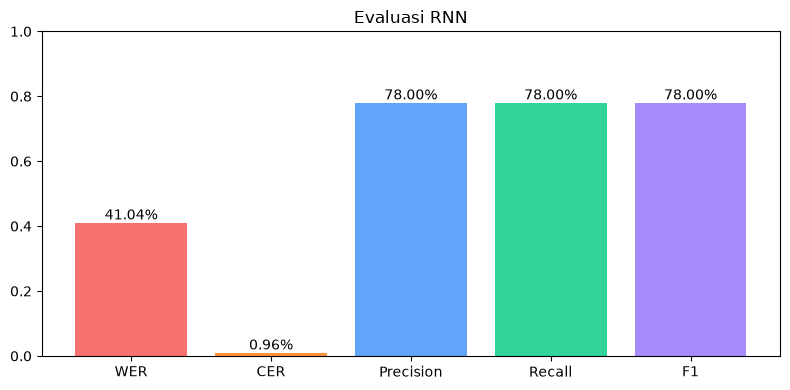

In [8]:
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    print('Matplotlib belum terpasang. Jalankan: .env\python.exe -m pip install matplotlib')
else:
    if not rows:
        print('Tidak ada hasil RNN untuk divisualisasikan.')
    else:
        labels = ['WER', 'CER', 'Precision', 'Recall', 'F1']
        values = [summary['wer_avg'], summary['cer_avg'], summary['precision_avg'], summary['recall_avg'], summary['f1_avg']]
        plt.figure(figsize=(8, 4))
        plt.bar(labels, values, color=['#f87171', '#fb923c', '#60a5fa', '#34d399', '#a78bfa'])
        plt.ylim(0, 1)
        plt.title('Evaluasi RNN')
        for i, value in enumerate(values):
            plt.text(i, value, f'{value:.2%}', ha='center', va='bottom')
        plt.tight_layout()
        plt.show()
